##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [54]:
import os
import re
import cv2
import zipfile
import random
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
%matplotlib inline

In [55]:
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

print("Seeds are set.")

Seeds are set.


In [56]:
from pathlib import Path

matches = [p for p in Path("/kaggle/input").rglob("action_youtube_naudio") if p.is_dir()]
print("Found:", matches)

student_name = "DalyaAlsalateen"

dataset_directory = str(matches[0])
archive_path = None
extract_to = "/kaggle/working/ucf11_data"

selected_classes = {
    "Basketball Shooting": ["basketball", "basketballshooting", "basketball_shooting"],
    "Biking/Cycling": ["biking", "cycling", "bikingcycling", "bike"],
    "Tennis Swinging": ["tennis", "tennisswing", "tennisswinging", "tennis_swing"],
}

image_height, image_width = 96, 96
frames_per_video = 30
max_videos_per_class = 120
batch_size = 32
epochs = 20

print("Configuration loaded.")
print("dataset_directory:", dataset_directory)

Found: [PosixPath('/kaggle/input/datasets/dalyasaeedalqahtani/ucf11-action-recognition/action_youtube_naudio')]
Configuration loaded.
dataset_directory: /kaggle/input/datasets/dalyasaeedalqahtani/ucf11-action-recognition/action_youtube_naudio


In [57]:
VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv", ".mpeg", ".mpg", ".wmv"}

def normalize_text(text):
    return re.sub(r"[^a-z0-9]+", "", str(text).lower())

def find_existing_path(path_candidates):
    for item in path_candidates:
        if item is None:
            continue
        p = Path(item)
        if p.exists():
            return p
    return None

def prepare_dataset_root(dataset_directory=None, archive_path="YouTube_DataSet_Annotated.zip", extract_to="ucf11_data"):
    """
    Returns the dataset root directory.
    - If dataset_directory exists, it is used directly.
    - Otherwise, if archive_path exists, it is extracted.
    """
    if dataset_directory is not None:
        dataset_dir = Path(dataset_directory)
        if dataset_dir.exists():
            return dataset_dir.resolve()
        raise FileNotFoundError(f"dataset_directory does not exist: {dataset_dir}")

    archive_candidates = [
        archive_path,
        Path.cwd() / archive_path,
        Path.cwd().parent / archive_path,
        Path("/content") / archive_path,
        Path("/mnt/data") / archive_path,
    ]
    archive_file = find_existing_path(archive_candidates)

    if archive_file is None:
        raise FileNotFoundError(
            "Dataset archive was not found.\n"
            "Please either:\n"
            "1) put YouTube_DataSet_Annotated.zip in the same folder as the notebook, or\n"
            "2) set dataset_directory to the extracted dataset folder path."
        )

    extract_dir = Path(extract_to)
    extract_dir.mkdir(parents=True, exist_ok=True)

    print(f"Using archive: {archive_file}")
    print(f"Extracting to: {extract_dir.resolve()}")

    with zipfile.ZipFile(archive_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    return extract_dir.resolve()

def collect_all_videos(root_dir):
    root_dir = Path(root_dir)
    return sorted([p for p in root_dir.rglob("*") if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS])

def path_matches_alias(video_path, aliases):
    parts = [normalize_text(part) for part in Path(video_path).parts]
    aliases = [normalize_text(a) for a in aliases]
    for part in parts:
        for alias in aliases:
            if alias in part or part in alias:
                return True
    return False

def build_selected_video_dict(all_video_paths, selected_classes, max_videos_per_class=120):
    selected_video_paths = {class_name: [] for class_name in selected_classes}
    for video_path in all_video_paths:
        for class_name, aliases in selected_classes.items():
            if path_matches_alias(video_path, aliases):
                selected_video_paths[class_name].append(Path(video_path))
                break

    for class_name in selected_video_paths:
        unique_paths = sorted(list(set(selected_video_paths[class_name])))
        random.shuffle(unique_paths)
        selected_video_paths[class_name] = unique_paths[:max_videos_per_class]
    return selected_video_paths

def extract_frames_from_video(video_path, image_height=64, image_width=64, frames_per_video=20):
    frames_list = []
    video_reader = cv2.VideoCapture(str(video_path))

    if not video_reader.isOpened():
        return frames_list

    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    if video_frames_count <= 0:
        video_reader.release()
        return frames_list

    frame_indices = np.linspace(0, max(video_frames_count - 1, 0), frames_per_video, dtype=int)

    for frame_index in frame_indices:
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
        success, frame = video_reader.read()
        if not success or frame is None:
            continue

        resized_frame = cv2.resize(frame, (image_width, image_height))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)

    video_reader.release()
    return frames_list

def create_frame_dataset(video_paths_by_class, class_to_index, image_height=64, image_width=64, frames_per_video=20):
    features = []
    labels = []
    metadata = []

    for class_name, video_paths in video_paths_by_class.items():
        class_index = class_to_index[class_name]
        for video_path in video_paths:
            frames = extract_frames_from_video(
                video_path,
                image_height=image_height,
                image_width=image_width,
                frames_per_video=frames_per_video,
            )
            for frame in frames:
                features.append(frame)
                labels.append(class_index)
                metadata.append({"video_path": str(video_path), "class_name": class_name})

    return np.asarray(features, dtype=np.float32), np.asarray(labels), metadata

def plot_sample_frames(video_paths_by_class, image_height=64, image_width=64):
    plt.figure(figsize=(15, 5))
    plot_index = 1

    for class_name, paths in video_paths_by_class.items():
        if len(paths) == 0:
            continue
        sample_video = random.choice(paths)
        frames = extract_frames_from_video(sample_video, image_height, image_width, frames_per_video=1)
        if len(frames) == 0:
            continue

        plt.subplot(1, len(video_paths_by_class), plot_index)
        plt.imshow(cv2.cvtColor((frames[0] * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
        plt.title(class_name)
        plt.axis("off")
        plot_index += 1

    plt.tight_layout()
    plt.show()

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(BatchNormalization())

    model.add(Dropout(0.30))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.30))
    model.add(Dense(num_classes, activation='softmax'))
    return model

def predict_video_class(model, video_path, class_names, image_height=64, image_width=64, frames_per_video=20):
    frames = extract_frames_from_video(
        video_path,
        image_height=image_height,
        image_width=image_width,
        frames_per_video=frames_per_video,
    )
    if len(frames) == 0:
        return None, None, None

    frames_np = np.asarray(frames, dtype=np.float32)
    predictions = model.predict(frames_np, verbose=0)
    average_scores = predictions.mean(axis=0)
    predicted_index = int(np.argmax(average_scores))
    predicted_label = class_names[predicted_index]
    confidence = float(average_scores[predicted_index])

    return predicted_label, confidence, average_scores

In [58]:
dataset_root = prepare_dataset_root(
    dataset_directory=dataset_directory,
    archive_path=archive_path,
    extract_to=extract_to,
)

print("Dataset root:", dataset_root)

Dataset root: /kaggle/input/datasets/dalyasaeedalqahtani/ucf11-action-recognition/action_youtube_naudio


In [59]:
from pathlib import Path
import random
import pandas as pd

all_video_paths = collect_all_videos(dataset_root)
print(f"Total videos found recursively: {len(all_video_paths)}")

# Show real top-level folders
top_level_folders = sorted({
    Path(vp).relative_to(dataset_root).parts[0].lower()
    for vp in all_video_paths
    if len(Path(vp).relative_to(dataset_root).parts) > 0
})
print("Top-level folders found:", top_level_folders)

selected_video_paths = {
    "Basketball Shooting": [],
    "Biking/Cycling": [],
    "Tennis Swinging": [],
}

for video_path in all_video_paths:
    rel_parts = Path(video_path).relative_to(dataset_root).parts
    if len(rel_parts) == 0:
        continue

    class_folder = rel_parts[0].lower()

    if class_folder in ["basketball", "basketballshooting", "basketball_shooting"]:
        selected_video_paths["Basketball Shooting"].append(Path(video_path))

    elif class_folder in ["biking", "cycling", "bikingcycling", "bike"]:
        selected_video_paths["Biking/Cycling"].append(Path(video_path))

    elif class_folder in ["tennis", "tennisswing", "tennisswinging", "tennis_swing"]:
        selected_video_paths["Tennis Swinging"].append(Path(video_path))

for class_name in selected_video_paths:
    unique_paths = sorted(list(set(selected_video_paths[class_name])))
    random.shuffle(unique_paths)
    selected_video_paths[class_name] = unique_paths[:max_videos_per_class]

summary_rows = []
for class_name, paths in selected_video_paths.items():
    summary_rows.append([class_name, len(paths)])

summary_df = pd.DataFrame(summary_rows, columns=["Class", "Videos Found"])
display(summary_df)

if (summary_df["Videos Found"] == 0).any():
    raise ValueError("At least one selected class was not found.")

Total videos found recursively: 1652
Top-level folders found: ['basketball', 'biking', 'diving', 'golf_swing', 'horse_riding', 'soccer_juggling', 'swing', 'tennis_swing', 'trampoline_jumping', 'volleyball_spiking', 'walking']


,Class,Videos Found
0,Basketball Shooting,120
1,Biking/Cycling,120
2,Tennis Swinging,120


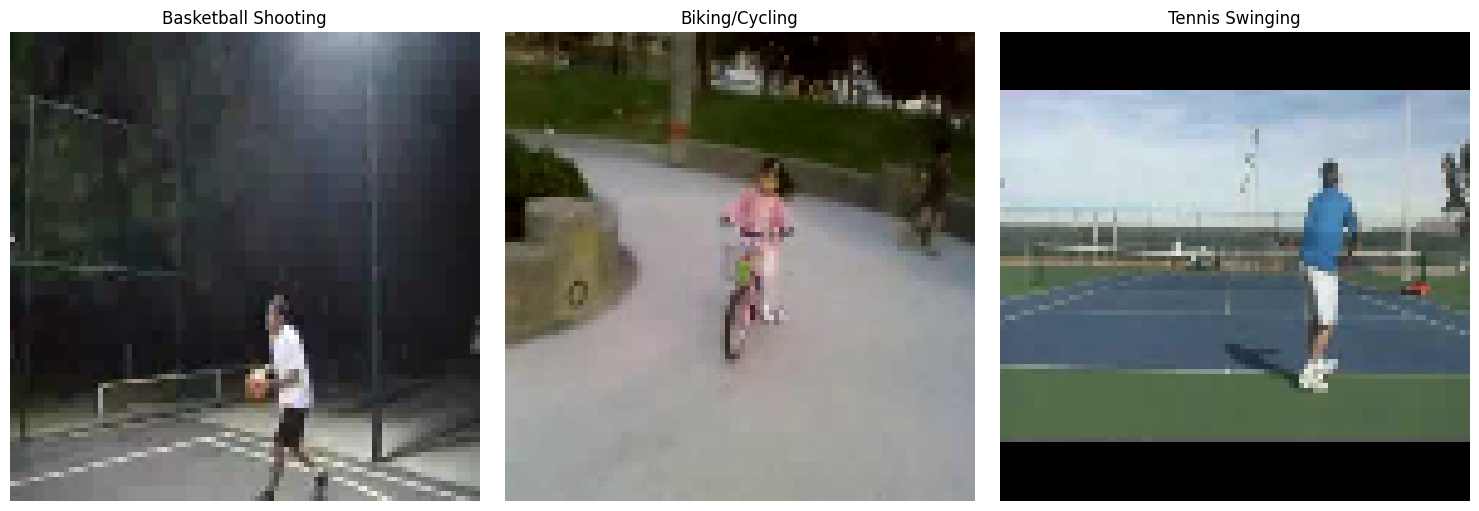

In [60]:
plot_sample_frames(selected_video_paths, image_height=image_height, image_width=image_width)

In [61]:
train_video_paths = {}
test_video_paths = {}

for class_name, video_paths in selected_video_paths.items():
    train_paths, test_paths = train_test_split(
        video_paths,
        test_size=train_test_ratio,
        shuffle=True,
        random_state=seed_constant,
    )
    train_video_paths[class_name] = train_paths
    test_video_paths[class_name] = test_paths

split_rows = []
for class_name in selected_classes.keys():
    split_rows.append([class_name, len(train_video_paths[class_name]), len(test_video_paths[class_name])])

split_df = pd.DataFrame(split_rows, columns=["Class", "Train Videos", "Test Videos"])
display(split_df)

,Class,Train Videos,Test Videos
0,Basketball Shooting,96,24
1,Biking/Cycling,96,24
2,Tennis Swinging,96,24


In [62]:
class_names = list(selected_classes.keys())
class_to_index = {class_name: index for index, class_name in enumerate(class_names)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

features_train, labels_train, train_metadata = create_frame_dataset(
    train_video_paths,
    class_to_index,
    image_height=image_height,
    image_width=image_width,
    frames_per_video=frames_per_video,
)
features_test, labels_test, test_metadata = create_frame_dataset(
    test_video_paths,
    class_to_index,
    image_height=image_height,
    image_width=image_width,
    frames_per_video=frames_per_video,
)

print("Training frames shape:", features_train.shape)
print("Testing frames shape :", features_test.shape)
print("Training labels shape:", labels_train.shape)
print("Testing labels shape :", labels_test.shape)

Training frames shape: (8611, 96, 96, 3)
Testing frames shape : (2160, 96, 96, 3)
Training labels shape: (8611,)
Testing labels shape : (2160,)


In [63]:
labels_train_encoded = to_categorical(labels_train, num_classes=len(class_names))
labels_test_encoded = to_categorical(labels_test, num_classes=len(class_names))

print("Encoded train labels shape:", labels_train_encoded.shape)
print("Encoded test labels shape :", labels_test_encoded.shape)

Encoded train labels shape: (8611, 3)
Encoded test labels shape : (2160, 3)


In [64]:
model = create_model(
    input_shape=(image_height, image_width, 3),
    num_classes=len(class_names)
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 47, 47, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,059 (6.61 MB)

 Trainable params: 1,732,611 (6.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [65]:
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    mode='min',
    restore_best_weights=True,
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_training_history = model.fit(
    x=features_train,
    y=labels_train_encoded,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.20,
    callbacks=[early_stopping_callback],
)

Epoch 1/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8497 - loss: 0.7272 - val_accuracy: 0.0000e+00 - val_loss: 25.7895
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9728 - loss: 0.1009 - val_accuracy: 0.0725 - val_loss: 10.1514
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9767 - loss: 0.1041 - val_accuracy: 0.9443 - val_loss: 0.2500
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9846 - loss: 0.0645 - val_accuracy: 0.7336 - val_loss: 7.1265
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9916 - loss: 0.0323 - val_accuracy: 0.6198 - val_loss: 5.8823
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9909 - loss: 0.0421 - val_accuracy: 0.7684 - val_loss: 4.1412
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9962 - loss: 0.0123 - val_accuracy: 0.7069 - val_loss: 9.9555
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9850 - loss: 0.0952 - v

In [67]:
test_loss, test_acc = model.evaluate(features_test, labels_test_encoded, verbose=0)
print("Test Loss =", test_loss)
print("Test Accuracy =", test_acc)

Test Loss = 1.0060303211212158
Test Accuracy = 0.9291666746139526


                     precision    recall  f1-score   support

Basketball Shooting       0.92      0.88      0.90       720
     Biking/Cycling       0.95      0.98      0.96       720
    Tennis Swinging       0.92      0.93      0.92       720

           accuracy                           0.93      2160
          macro avg       0.93      0.93      0.93      2160
       weighted avg       0.93      0.93      0.93      2160



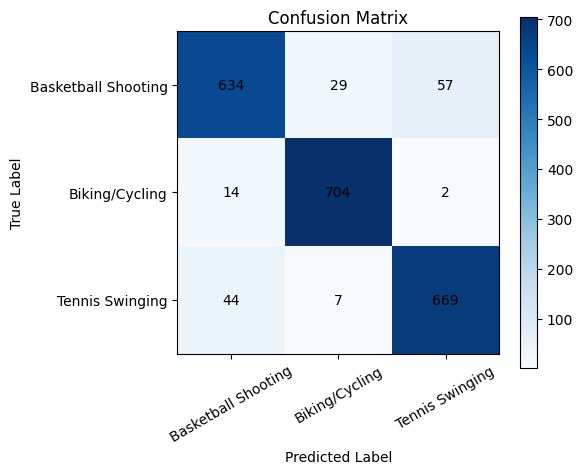

In [68]:
predictions_test = model.predict(features_test, verbose=0)
predicted_labels_test = np.argmax(predictions_test, axis=1)

print(classification_report(labels_test, predicted_labels_test, target_names=class_names))

cm = confusion_matrix(labels_test, predicted_labels_test)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=30)
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

In [69]:
if student_name.strip().replace(',', '').strip() == "":
    raise ValueError("Please replace student_name with your actual name before saving the final model.")

safe_student_name = re.sub(r"\s+", "_", student_name.strip())
save_path = f"{safe_student_name}_ucf11_model.h5"
model.save(save_path)

print(f"Model saved as: {save_path}")

Model saved as: DalyaAlsalateen_ucf11_model.h5


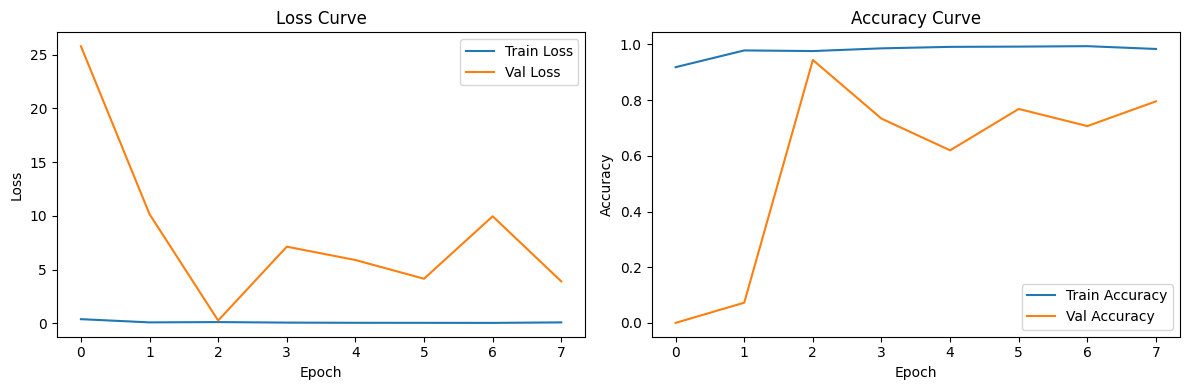

In [70]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model_training_history.history['loss'], label='Train Loss')
plt.plot(model_training_history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(model_training_history.history['accuracy'], label='Train Accuracy')
plt.plot(model_training_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
video_level_results = []

for true_class_name, paths in test_video_paths.items():
    for video_path in paths:
        predicted_label, confidence, scores = predict_video_class(
            model,
            video_path,
            class_names,
            image_height=image_height,
            image_width=image_width,
            frames_per_video=frames_per_video,
        )

        video_level_results.append({
            "video_path": str(video_path),
            "true_label": true_class_name,
            "predicted_label": predicted_label,
            "confidence": round(confidence, 4) if confidence is not None else None,
            "correct": predicted_label == true_class_name if predicted_label is not None else False,
        })

video_level_df = pd.DataFrame(video_level_results)
display(video_level_df.head(15))

video_level_accuracy = video_level_df['correct'].mean() if len(video_level_df) > 0 else 0
print(f"Video-level test accuracy: {video_level_accuracy:.2%}")

,video_path,true_label,predicted_label,confidence,correct
0,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Tennis Swinging,1.0000,False
1,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,0.9998,True
2,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,1.0000,True
3,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,0.9824,True
4,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,1.0000,True
5,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,0.9998,True
6,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,0.8112,True
7,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,0.9996,True
8,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,0.9934,True
9,/kaggle/input/datasets/dalyasaeedalqahtani/ucf...,Basketball Shooting,Basketball Shooting,1.0000,True


Video-level test accuracy: 94.44%


In [73]:
!pip install -q yt-dlp

external_video_sources = [
    "https://www.youtube.com/watch?v=OIBjZ9hxt38",  # Basketball Shooting
    "https://www.youtube.com/watch?v=_vdX8QZyWeI",  # Biking/Cycling
    "https://www.youtube.com/watch?v=8V_KWh1Uoeo",  # Tennis Swinging
]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 69.0 MB/s eta 0:00:00:00:01


In [74]:
def resolve_external_video(source, download_dir="external_videos"):
    source = str(source)

    local_path = Path(source)
    if local_path.exists():
        return local_path.resolve()

    if source.startswith("http://") or source.startswith("https://"):
        try:
            import yt_dlp
        except ImportError:
            raise ImportError(
                "yt-dlp is not installed. Uncomment the install cell above if you want to use YouTube links."
            )

        download_dir = Path(download_dir)
        download_dir.mkdir(parents=True, exist_ok=True)

        output_template = str(download_dir / "%(title)s.%(ext)s")
        ydl_opts = {
            "format": "mp4/bestvideo+bestaudio/best",
            "outtmpl": output_template,
            "quiet": True,
            "noplaylist": True,
        }

        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(source, download=True)
            downloaded_path = Path(ydl.prepare_filename(info))

        return downloaded_path.resolve()

    raise FileNotFoundError(f"Could not resolve external source: {source}")


external_results = []

if len(external_video_sources) == 0:
    print("Please add your 3 external videos in the previous cell, then run this cell again.")
else:
    for source in external_video_sources:
        video_path = resolve_external_video(source)
        predicted_label, confidence, scores = predict_video_class(
            model,
            video_path,
            class_names,
            image_height=image_height,
            image_width=image_width,
            frames_per_video=frames_per_video,
        )

        external_results.append({
            "video": str(video_path),
            "predicted_label": predicted_label,
            "confidence": round(confidence, 4) if confidence is not None else None,
        })

    external_results_df = pd.DataFrame(external_results)
    display(external_results_df)

,video,predicted_label,confidence
0,/kaggle/working/external_videos/30 Minute HIGH...,Basketball Shooting,0.9937
1,/kaggle/working/external_videos/Countryside Ro...,Biking/Cycling,0.5116
2,/kaggle/working/external_videos/Amazing Tennis...,Tennis Swinging,0.6956
